# Exploratory Data Analysis

Credit Card Fraud Detection dataset from Kaggle.

## Imports

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

## Load Data

In [9]:
df = pd.read_csv('../01_data/creditcard.csv')
print(f"Shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()

Shape: 284,807 rows, 31 columns


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Data Info

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [11]:
# Missing values
print(f"Missing values: {df.isnull().sum().sum()}")

Missing values: 0


In [12]:
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes} ({dupes/len(df)*100:.2f}%)")

Duplicate rows: 1081 (0.38%)


## Target Distribution

In [13]:
fraud_counts = df['Class'].value_counts()
fraud_pct = df['Class'].value_counts(normalize=True) * 100

print(f"Legitimate: {fraud_counts[0]:,} ({fraud_pct[0]:.2f}%)")
print(f"Fraud:      {fraud_counts[1]:,} ({fraud_pct[1]:.2f}%)")

Legitimate: 284,315 (99.83%)
Fraud:      492 (0.17%)


C:\Users\jensg\AppData\Local\Temp\ipykernel_2664\2127682261.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Legitimate', 'Fraud'])


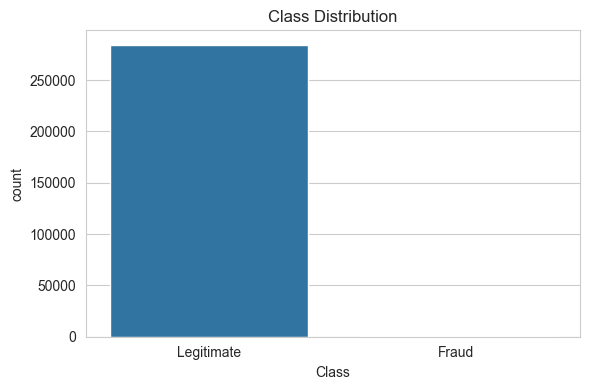


Imbalance ratio: 577:1


In [15]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x='Class', ax=ax)
ax.set_xticklabels(['Legitimate', 'Fraud'])
ax.set_title('Class Distribution')
plt.tight_layout()
plt.show()
print(f"\nImbalance ratio: {fraud_counts[0] // fraud_counts[1]}:1")

## Amount and Time

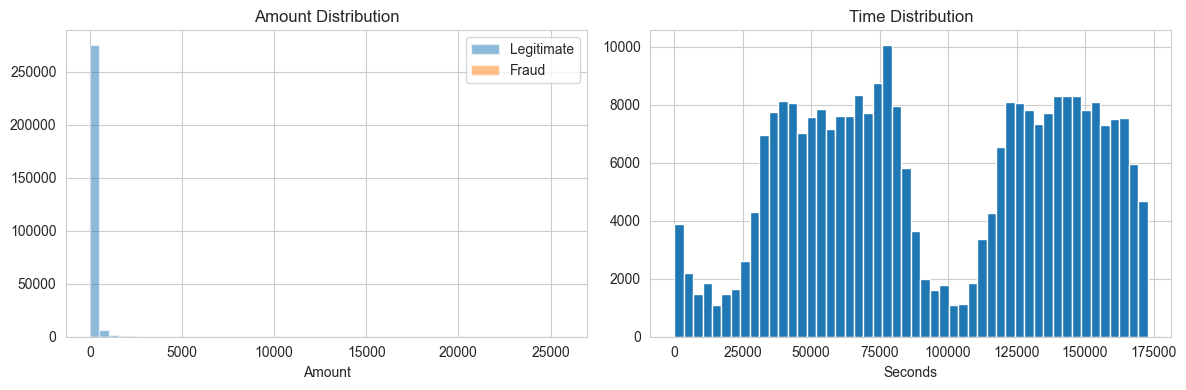

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Amount distribution by class
ax1 = axes[0]
df[df['Class']==0]['Amount'].hist(bins=50, alpha=0.5, label='Legitimate', ax=ax1)
df[df['Class']==1]['Amount'].hist(bins=50, alpha=0.5, label='Fraud', ax=ax1)
ax1.set_title('Amount Distribution')
ax1.set_xlabel('Amount')
ax1.legend()

# Time distribution
ax2 = axes[1]
df['Time'].hist(bins=50, ax=ax2)
ax2.set_title('Time Distribution')
ax2.set_xlabel('Seconds')

plt.tight_layout()
plt.show()

In [17]:
print("Amount stats by class:")
print(df.groupby('Class')['Amount'].describe())

Amount stats by class:
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


In [18]:
# Correlation with target
correlations = df.corr()['Class'].drop('Class').sort_values()
print("Most negatively correlated with fraud:")
print(correlations.head(5))
print("\nMost positively correlated with fraud:")
print(correlations.tail(5))

Most negatively correlated with fraud:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
Name: Class, dtype: float64

Most positively correlated with fraud:
V19    0.034783
V21    0.040413
V2     0.091289
V4     0.133447
V11    0.154876
Name: Class, dtype: float64


### Findings
- V17, V14, V12 have strongest negative correlation with fraud (lower values → more likely fraud)
- V11, V4 have strongest positive correlation (higher values → more likely fraud)
- All correlations are weak (< 0.35) - expected for rare fraud patterns
- Amount and Time show minimal correlation with fraud